# Análisis exploratorio de datos

Contentesta las siguientes preguntas escribiendo el código de Python necesario para encontrar las respuestas o producir las gráficas necesarias

---


In [3]:
# No mostrar advertencias
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Importar datos
df = pd.read_csv("data/retailmax.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 1. ¿Cuál es la distribución de edades de los clientes?
- **Objetivo**: Comprender la distribución de las edades en el conjunto de datos.
- **Respuesta esperada**: Un histograma de la columna Age.

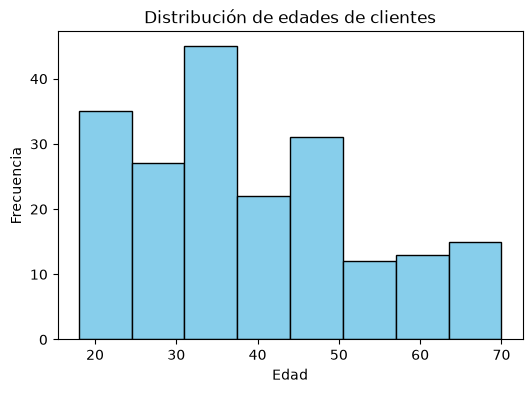

In [5]:
# Histograma de edades
plt.figure(figsize=(6,4))
plt.hist(df["Age"], bins=8, color="skyblue", edgecolor="black")
plt.title("Distribución de edades de clientes")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()


**RESPUESTA:**

La distribución de edades muestra mayor concentración en adultos jóvenes (20–40 años), con un pico alrededor de los 30–35 años.  
Las edades mayores (50–70) tienen menor frecuencia, indicando que el público principal son clientes jóvenes y adultos medios.

### 2. ¿Existen diferencias significativas en los ingresos anuales entre hombres y mujeres?
- **Objetivo**: Comparar la distribución de ingresos anuales entre géneros.
- **Respuesta esperada**: Una gráfica de cajas (boxplot) que muestre la distribución de Annual Income (k$) por género.

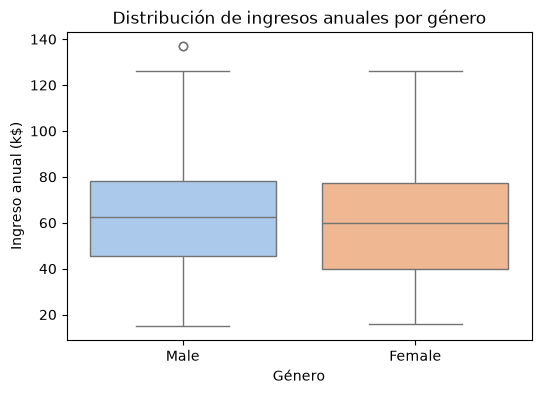

In [7]:
# Boxplot de ingresos por género
plt.figure(figsize=(6,4))
sns.boxplot(x="Gender", y="Annual Income (k$)", data=df, palette="pastel")
plt.title("Distribución de ingresos anuales por género")
plt.xlabel("Género")
plt.ylabel("Ingreso anual (k$)")
plt.show()

**RESPUESTA:**

El boxplot muestra que los ingresos anuales de hombres y mujeres son similares en mediana y rango, sin diferencias marcadas.  
Ambos géneros presentan amplia variabilidad, aunque los hombres tienen un outlier alto (~135 k$).   
No parece existir diferencia significativa entre grupos.

### 3. ¿Cómo se distribuye la puntuación de gasto (Spending Score) entre los diferentes rangos de edad?
- **Objetivo**: Analizar la relación entre la edad y la puntuación de gasto.
- **Respuesta esperada**: Una gráfica de dispersión (scatter plot) o un gráfico de cajas que compare la Spending Score (1-100) con diferentes grupos de edad.

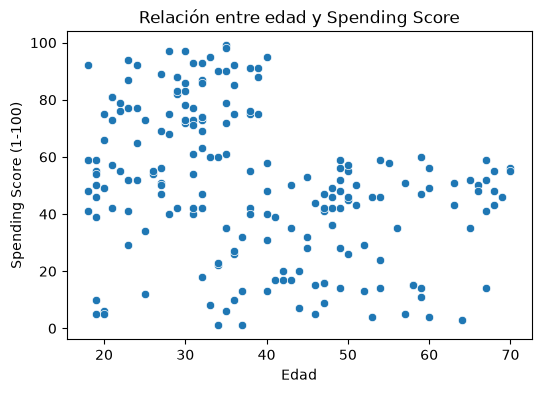

In [11]:
# Gráfica de dispersión Age vs Spending Score
plt.figure(figsize=(6,4))
sns.scatterplot(x="Age", y="Spending Score (1-100)", data=df, palette="Set2")
plt.title("Relación entre edad y Spending Score")
plt.xlabel("Edad")
plt.ylabel("Spending Score (1-100)")
plt.show()

**RESPUESTA:**

La puntuación de gasto muestra alta dispersión en edades jóvenes (≈ 20–35 años), con valores que van de muy bajos a muy altos.  
A medida que aumenta la edad, los Spending Scores tienden a concentrarse en rangos medios (≈ 40–60), indicando que los clientes jóvenes son más variables y los mayores más consistentes en su gasto.

### 4. ¿Cuál es la correlación entre el ingreso anual y la puntuación de gasto?
- **Objetivo**: Identificar si existe una relación lineal entre el ingreso y el gasto.
- **Respuesta esperada**: Una gráfica de dispersión y el cálculo del coeficiente de correlación entre Annual Income (k$) y Spending Score (1-100).

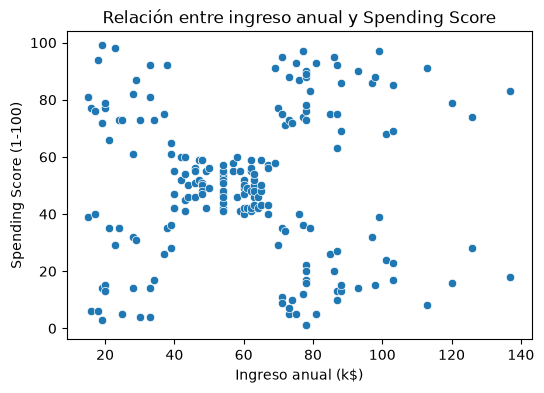

Coeficiente de correlación: 0.009902848094037606


In [10]:
# Gráfica de dispersión Income vs Spending Score
plt.figure(figsize=(6,4))
sns.scatterplot(x="Annual Income (k$)", y="Spending Score (1-100)", data=df, palette="Set1")
plt.title("Relación entre ingreso anual y Spending Score")
plt.xlabel("Ingreso anual (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

# Cálculo de correlación (Pearson)
corr = df["Annual Income (k$)"].corr(df["Spending Score (1-100)"])
print("Coeficiente de correlación:", corr)

**RESPUESTA:**

La gráfica de dispersión muestra que no existe una relación lineal clara entre el ingreso anual y la puntuación de gasto.  
Los puntos están distribuidos de forma dispersa, con clientes de ingresos bajos y altos mostrando tanto Spending Scores altos como bajos.  
Esto indica una correlación débil o casi nula, es decir, el nivel de ingreso no determina directamente el gasto en este conjunto de datos.

### 5. ¿Cómo varía la puntuación de gasto en diferentes grupos de ingresos anuales?

- **Objetivo**: Examinar cómo los clientes en diferentes rangos de ingresos se comportan en términos de gasto.
- **Respuesta esperada**: Una gráfica de cajas o de violín que muestre la Spending Score (1-100) para diferentes rangos de Annual Income (k$).

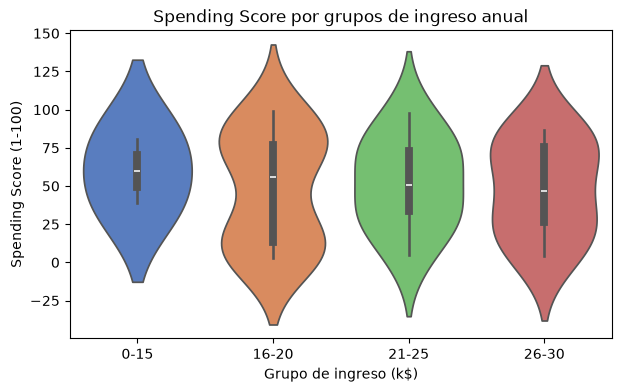

In [12]:
# Crear grupos de ingreso (ejemplo)
df["IncomeGroup"] = pd.cut(df["Annual Income (k$)"],
                           bins=[0,15,20,25,30],
                           labels=["0-15","16-20","21-25","26-30"])

# Gráfico de violín
plt.figure(figsize=(7,4))
sns.violinplot(x="IncomeGroup", y="Spending Score (1-100)", data=df, palette="muted")
plt.title("Spending Score por grupos de ingreso anual")
plt.xlabel("Grupo de ingreso (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

**RESPUESTA:**

La puntuación de gasto varía ampliamente en todos los grupos de ingreso anual.  
Los clientes con ingresos bajos (0–15 k$ y 16–20 k$) muestran la mayor dispersión, con tanto valores altos como bajos de Spending Score.  
En los grupos medios (21–25 k$ y 26–30 k$) la distribución es más concentrada, indicando comportamientos de gasto más consistentes.  
En conjunto, el nivel de ingreso no determina directamente el gasto, pero los rangos bajos presentan mayor diversidad en hábitos de consumo.

### 6. ¿Cuál es la proporción de clientes por género?
- **Objetivo**: Determinar el balance de género en el conjunto de datos.
- **Respuesta esperada**: Una gráfica de barras o un gráfico de pastel que muestre la proporción de hombres y mujeres.

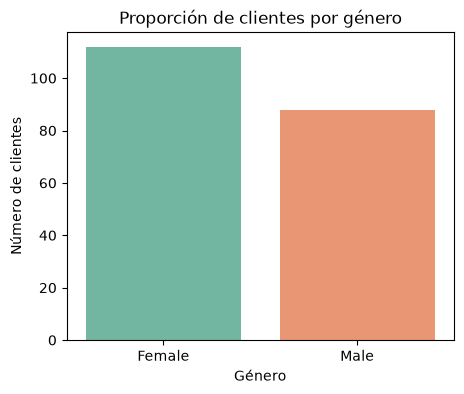

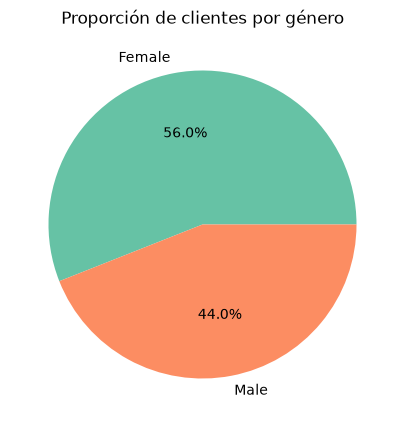

In [13]:
# Conteo por género
gender_counts = df["Gender"].value_counts()

# Gráfico de barras
plt.figure(figsize=(5,4))
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette="Set2")
plt.title("Proporción de clientes por género")
plt.xlabel("Género")
plt.ylabel("Número de clientes")
plt.show()

# Gráfico de pastel
plt.figure(figsize=(5,5))
plt.pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%", colors=["#66c2a5","#fc8d62"])
plt.title("Proporción de clientes por género")
plt.show()


**RESPUESTA:**

La proporción de clientes por género muestra que hay más mujeres (≈ 110) que hombres (≈ 88) en el conjunto de datos.  
Esto indica un predominio femenino en la base de clientes, lo que puede influir en estrategias de segmentación y marketing orientadas a ese grupo.

### 7. ¿Qué grupos de edad gastan más en promedio?
- **Objetivo**: Identificar los grupos de edad que tienen una mayor puntuación de gasto en promedio.
- **Respuesta esperada**: Una gráfica de barras que compare la puntuación de gasto promedio entre diferentes grupos de edad.

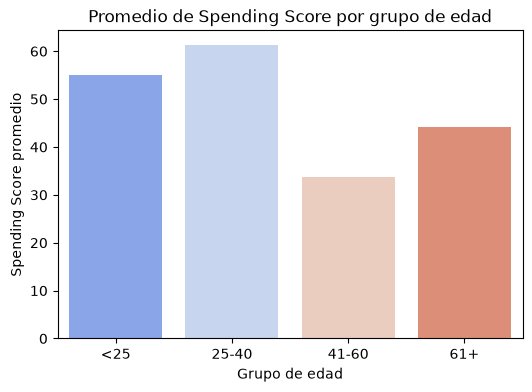

In [14]:
# Crear grupos de edad
df["AgeGroup"] = pd.cut(df["Age"],
                        bins=[0,25,40,60,80],
                        labels=["<25","25-40","41-60","61+"])

# Calcular promedio de Spending Score por grupo
age_spending = df.groupby("AgeGroup")["Spending Score (1-100)"].mean().reset_index()

# Gráfico de barras
plt.figure(figsize=(6,4))
sns.barplot(x="AgeGroup", y="Spending Score (1-100)", data=age_spending, palette="coolwarm")
plt.title("Promedio de Spending Score por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Spending Score promedio")
plt.show()


**RESPUESTA:**

Los grupos de edad que más gastan en promedio son los de 25–40 años, seguidos por los menores de 25.  
Los adultos de 41–60 presentan el gasto más bajo, mientras que los mayores de 61 muestran un nivel intermedio.  
Esto indica que los clientes jóvenes y adultos medios son los segmentos con mayor Spending Score promedio y, por tanto, los más relevantes para estrategias de marketing.

### 8. ¿Hay alguna relación entre la edad y el ingreso anual de los clientes?
- **Objetivo**: Explorar si hay una tendencia entre la edad de los clientes y sus ingresos.
- **Respuesta esperada**: Una gráfica de dispersión que muestre la relación entre Age y Annual Income (k$).

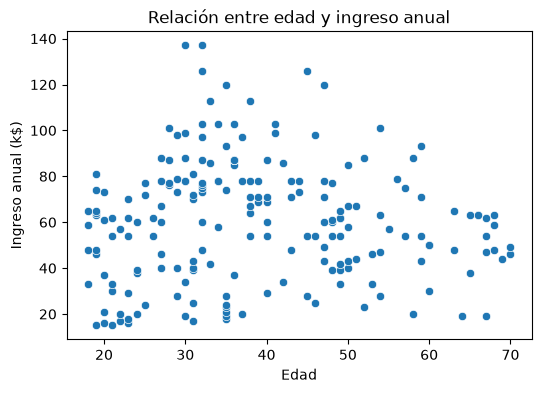

Coeficiente de correlación: -0.012398042736060138


In [16]:
# Gráfica de dispersión Age vs Annual Income
plt.figure(figsize=(6,4))
sns.scatterplot(x="Age", y="Annual Income (k$)", data=df, palette="Set2")
plt.title("Relación entre edad y ingreso anual")
plt.xlabel("Edad")
plt.ylabel("Ingreso anual (k$)")
plt.show()

# Correlación Pearson
corr = df["Age"].corr(df["Annual Income (k$)"])
print("Coeficiente de correlación:", corr)


**RESPUESTA:**

La gráfica de dispersión muestra que no hay una relación lineal clara entre la edad y el ingreso anual.  
Los puntos están distribuidos de forma amplia en todas las edades, con ingresos variados tanto en jóvenes como en adultos mayores.  
Esto indica una correlación débil o casi nula, es decir, la edad no explica directamente el nivel de ingreso en este conjunto de clientes.

### 9. ¿Cuál es la distribución conjunta de la edad y el ingreso anual?
- **Objetivo**: Entender cómo se distribuyen estas dos variables en conjunto.
- **Respuesta esperada**: Una gráfica de dispersión con una densidad de puntos o un gráfico de hexágonos que muestre la distribución conjunta de Age y Annual Income (k$).

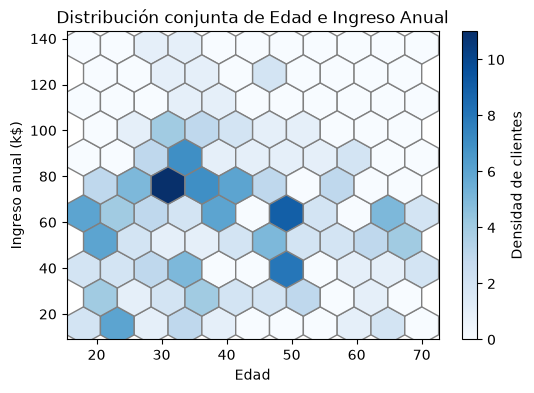

In [17]:
# Scatter plot con densidad (hexbin)
plt.figure(figsize=(6,4))
plt.hexbin(df["Age"], df["Annual Income (k$)"], gridsize=10, cmap="Blues", edgecolors="grey")
plt.title("Distribución conjunta de Edad e Ingreso Anual")
plt.xlabel("Edad")
plt.ylabel("Ingreso anual (k$)")
plt.colorbar(label="Densidad de clientes")
plt.show()


**RESPUESTA:**

La distribución conjunta de edad e ingreso anual muestra una mayor densidad de clientes entre los 25 y 40 años con ingresos de 60 a 80 k$, donde los hexágonos son más oscuros.  
A medida que aumenta la edad, la densidad disminuye y los ingresos se vuelven más dispersos.  
En resumen, la mayoría de los clientes son adultos jóvenes con ingresos medios, mientras que los extremos de edad e ingreso son menos frecuentes.

### 10. ¿Cómo se distribuyen los clientes en función de la puntuación de gasto y el género?
- **Objetivo**: Analizar la relación entre la puntuación de gasto y el género.
- **Respuesta esperada**: Una gráfica de dispersión o un gráfico de violín que muestre la Spending Score (1-100) separada por género.

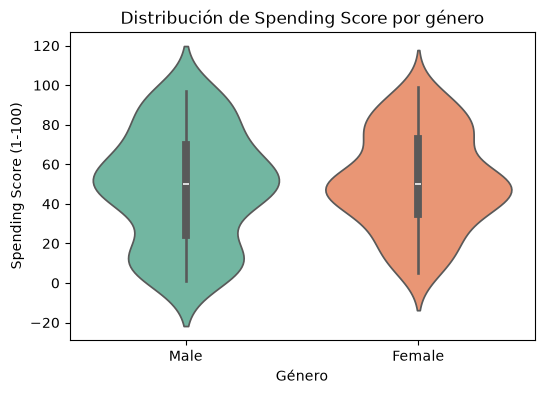

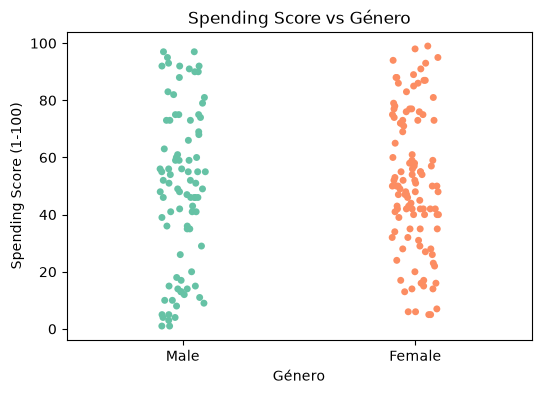

In [19]:
# Gráfico de violín Spending Score por género
plt.figure(figsize=(6,4))
sns.violinplot(x="Gender", y="Spending Score (1-100)", data=df, palette="Set2")
plt.title("Distribución de Spending Score por género")
plt.xlabel("Género")
plt.ylabel("Spending Score (1-100)")
plt.show()

# Alternativa: scatter plot
plt.figure(figsize=(6,4))
sns.stripplot(x="Gender", y="Spending Score (1-100)", data=df, jitter=True, palette="Set2")
plt.title("Spending Score vs Género")
plt.xlabel("Género")
plt.ylabel("Spending Score (1-100)")
plt.show()


**RESPUESTA:**

La distribución de Spending Score por género muestra que ambos grupos tienen una amplia variabilidad en sus puntuaciones, con medianas similares.  
Sin embargo, las mujeres presentan una ligera mayor dispersión, lo que sugiere comportamientos de gasto más diversos.  
En conjunto, no hay diferencias marcadas en el promedio, pero sí una mayor variabilidad en el consumo femenino, útil para segmentar estrategias de marketing.